# Bài 4: Tối ưu hóa Hồi quy Logistic với L2 Regularization (MAP) bằng Gradient Ascent

## 1. Mô tả bài toán
- Cài đặt thuật toán **Hồi quy Logistic (Logistic Regression)** cho bài toán phân loại nhị phân ($y \in \{0, 1\}$).
- Hàm mục tiêu kết hợp **hàm hợp lý Bernoulli (Bernoulli Likelihood)** và **tiên nghiệm chuẩn Gaussian (L2 Regularization)** cho vector trọng số $w$ theo nguyên lý **Cực đại hóa hậu nghiệm (MAP)**.
- Sử dụng thuật toán **Gradient Ascent (Leo đồi / Tăng độ dốc)** để trực tiếp tối đa hóa hàm Log-posterior.
- Thử nghiệm trên tập dữ liệu phi tuyến tính `make_moons` kết hợp mở rộng đặc trưng đa thức bậc cao để trực quan hóa cách hệ số $\lambda$ kiểm soát hiện tượng **quá khớp (Overfitting)**.

## 2. Cơ sở lý thuyết & Công thức toán học

### a. Hàm hợp lý Bernoulli (Likelihood) & Sigmoid:
Mỗi mẫu $x_i$ có xác suất dự đoán nhãn dương $y_i = 1$ thông qua hàm Sigmoid:
$$p_i = P(y_i = 1 \mid x_i, w) = \sigma(w^T x_i) = \frac{1}{1 + e^{-w^T x_i}}$$
Hàm hợp lý Bernoulli cho toàn bộ tập dữ liệu độc lập:
$$P(y \mid X, w) = \prod_{i=1}^N p_i^{y_i} (1 - p_i)^{1 - y_i}$$
Log-likelihood tương ứng:
$$\ln P(y \mid X, w) = \sum_{i=1}^N \left[ y_i \ln p_i + (1 - y_i) \ln(1 - p_i) \right]$$

### b. Tiên nghiệm chuẩn Gaussian (L2 Prior):
Giả định tiên nghiệm chuẩn cho các trọng số $w \sim \mathcal{N}(0, \tau^2 I)$ (không phạt bias $w_0$):
$$P(w) \propto \exp\left(-\frac{1}{2\tau^2} \sum_{j=1}^D w_j^2\right) = \exp\left(-\frac{\lambda}{2} \|w_{reg}\|_2^2\right)$$
với $\lambda = \frac{1}{\tau^2} \ge 0$ và $w_{reg} = [0, w_1, w_2, \dots, w_D]^T$.

### c. Hàm mục tiêu Log-posterior (Yêu cầu 1):
Theo định lý Bayes, Log-posterior là:
$$J(w) = \ln P(w \mid X, y) = \sum_{i=1}^N \left[ y_i \ln \sigma(w^T x_i) + (1 - y_i) \ln(1 - \sigma(w^T x_i)) \right] - \frac{\lambda}{2} \sum_{j=1}^D w_j^2$$

### d. Gradient & Thuật toán Gradient Ascent (Yêu cầu 2):
Đạo hàm riêng của $J(w)$ theo $w$:
$$\nabla_w J(w) = \sum_{i=1}^N (y_i - p_i) x_i - \lambda w_{reg} = X^T (y - p) - \lambda w_{reg}$$
Vì cần **tối đa hóa** hàm Log-posterior $J(w)$, ta sử dụng thuật toán **Gradient Ascent (đi theo hướng cùng chiều với Gradient)**:
$$w^{(t+1)} = w^{(t)} + \eta \cdot \frac{\nabla_w J(w^{(t)})}{N}$$
với $\eta > 0$ là tốc độ học (Learning Rate), và chia cho $N$ để chuẩn hóa độ lớn bước nhảy theo kích thước mẫu.

In [1]:
# 0. Import thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

# Cố định random seed để kết quả mô phỏng có thể tái lập
np.random.seed(42)

In [2]:
# ==============================================================================
# YÊU CẦU 1 & 2: Cài đặt Hàm Log-posterior và Thuật toán Gradient Ascent
# ==============================================================================

def sigmoid(z):
    """Hàm kích hoạt Sigmoid an toàn chống tràn số (overflow)."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -25.0, 25.0)))

def compute_log_posterior(w, X, y, lmbda):
    """
    YÊU CẦU 1: Tính hàm mục tiêu Log-posterior:
    J(w) = Log-likelihood (Bernoulli) - (lambda / 2) * ||w_reg||^2
    (Không phạt trọng số bias w[0])
    """
    p = sigmoid(X @ w)
    eps = 1e-15  # Tránh lỗi log(0)
    p = np.clip(p, eps, 1.0 - eps)
    
    # Thành phần Log-likelihood Bernoulli
    log_likelihood = np.sum(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    
    # Thành phần tiên nghiệm chuẩn L2 (không phạt bias w[0])
    log_prior = -0.5 * lmbda * np.sum(w[1:] ** 2)
    
    return log_likelihood + log_prior

def train_logistic_regression_map(X, y, lmbda=1.0, lr=0.8, n_iters=3000):
    """
    YÊU CẦU 2: Thuật toán Gradient Ascent tối ưu hóa hàm mục tiêu theo trọng số w.
    Cập nhật: w = w + lr * (grad / N)
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    history_log_posterior = []

    for it in range(n_iters):
        p = sigmoid(X @ w)
        
        # 1. Gradient của Log-likelihood: X^T (y - p)
        grad_likelihood = X.T @ (y - p)
        
        # 2. Gradient của Log-prior L2: - lambda * w_reg
        grad_prior = np.zeros_like(w)
        grad_prior[1:] = -lmbda * w[1:]
        
        # 3. Gradient tổng của Log-posterior
        grad = grad_likelihood + grad_prior
        
        # 4. Cập nhật Gradient Ascent (leo đồi để cực đại hóa J(w))
        w += lr * (grad / n_samples)
        
        # Lưu vết hội tụ sau mỗi 50 vòng lặp
        if it % 50 == 0 or it == n_iters - 1:
            history_log_posterior.append(compute_log_posterior(w, X, y, lmbda))
            
    return w, history_log_posterior

def predict(X, w):
    """Dự đoán nhãn nhị phân (ngưỡng xác suất 0.5)."""
    return (sigmoid(X @ w) >= 0.5).astype(int)

In [3]:
# ==============================================================================
# YÊU CẦU 3: Tập dữ liệu phi tuyến tính make_moons & Mở rộng đặc trưng đa thức
# ==============================================================================

# Hàm tạo make_moons (dùng sklearn nếu có, hoặc NumPy thuần túy)
def generate_make_moons(n_samples=200, noise=0.25, random_state=42):
    try:
        from sklearn.datasets import make_moons
        return make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    except ImportError:
        np.random.seed(random_state)
        n_out = n_samples // 2
        n_in = n_samples - n_out
        theta_out = np.linspace(0, np.pi, n_out)
        theta_in = np.linspace(0, np.pi, n_in)
        x_out = np.column_stack([np.cos(theta_out), np.sin(theta_out)])
        x_in = np.column_stack([1.0 - np.cos(theta_in), 1.0 - np.sin(theta_in) - 0.5])
        X = np.vstack([x_out, x_in])
        y = np.hstack([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
        if noise:
            X += np.random.normal(scale=noise, size=X.shape)
        perm = np.random.permutation(n_samples)
        return X[perm], y[perm]

X_raw, y = generate_make_moons(n_samples=200, noise=0.25, random_state=42)

# Chia tập Train (70%) và Test (30%)
n_train = int(0.7 * len(X_raw))
X_train_raw, X_test_raw = X_raw[:n_train], X_raw[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Hàm mở rộng đặc trưng đa thức bậc cao (Polynomial Feature Mapping)
def map_polynomial_features(X, degree=6):
    """
    Mở rộng không gian đặc trưng từ (x1, x2) sang đa thức bậc 6:
    Phi(x) = [1, x1, x2, x1^2, x1*x2, x2^2, ..., x2^6]
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    out = [np.ones(len(x1))]  # Cột bias x0 = 1
    for d in range(1, degree + 1):
        for i in range(d + 1):
            out.append((x1 ** (d - i)) * (x2 ** i))
    return np.column_stack(out)

degree = 6
X_train = map_polynomial_features(X_train_raw, degree=degree)
X_test = map_polynomial_features(X_test_raw, degree=degree)

print(f"Số lượng mẫu Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Số chiều đặc trưng sau khi mở rộng đa thức bậc {degree}: {X_train.shape[1]} chiều")

Số lượng mẫu Train: 140 | Test: 60
Số chiều đặc trưng sau khi mở rộng đa thức bậc 6: 28 chiều


In [4]:
# ==============================================================================
# YÊU CẦU 3: Thử nghiệm với các mức lambda khác nhau
# ==============================================================================
# Khảo sát 3 kịch bản chính:
# 1. lambda = 0.0:  Không điều chuẩn (MLE) -> Quá khớp (Overfitting)
# 2. lambda = 1.0:  Điều chuẩn vừa phải (MAP tối ưu) -> Tổng quát hóa tốt (Balanced)
# 3. lambda = 100.0: Điều chuẩn quá mạnh (MAP) -> Thiếu khớp (Underfitting)

lambda_configs = [0.0, 1.0, 100.0]
results = {}

print("=" * 85)
print(f"{'Lambda':<10} | {'Train Acc (%)':<15} | {'Test Acc (%)':<15} | {'Chuẩn ||w||_2':<15} | {'Nhận định':<20}")
print("=" * 85)

for lmb in lambda_configs:
    w_fit, history = train_logistic_regression_map(X_train, y_train, lmbda=lmb, lr=0.8, n_iters=4000)
    train_acc = np.mean(predict(X_train, w_fit) == y_train) * 100.0
    test_acc = np.mean(predict(X_test, w_fit) == y_test) * 100.0
    norm_w = np.linalg.norm(w_fit[1:])
    
    if lmb == 0.0:
        verdict = "Overfitting (Quá khớp)"
    elif lmb == 1.0:
        verdict = "Optimal (Tối ưu)"
    else:
        verdict = "Underfitting (Thiếu khớp)"
        
    print(f"{lmb:<10.1f} | {train_acc:<15.2f} | {test_acc:<15.2f} | {norm_w:<15.3f} | {verdict:<20}")
    results[lmb] = {'w': w_fit, 'history': history, 'train_acc': train_acc, 'test_acc': test_acc}
print("=" * 85)

Lambda     | Train Acc (%)   | Test Acc (%)    | Chuẩn ||w||_2   | Nhận định           
0.0        | 96.43           | 90.00           | 14.650          | Overfitting (Quá khớp)
1.0        | 93.57           | 91.67           | 3.960           | Optimal (Tối ưu)    
100.0      | 75.71           | 75.00           | 0.447           | Underfitting (Thiếu khớp)


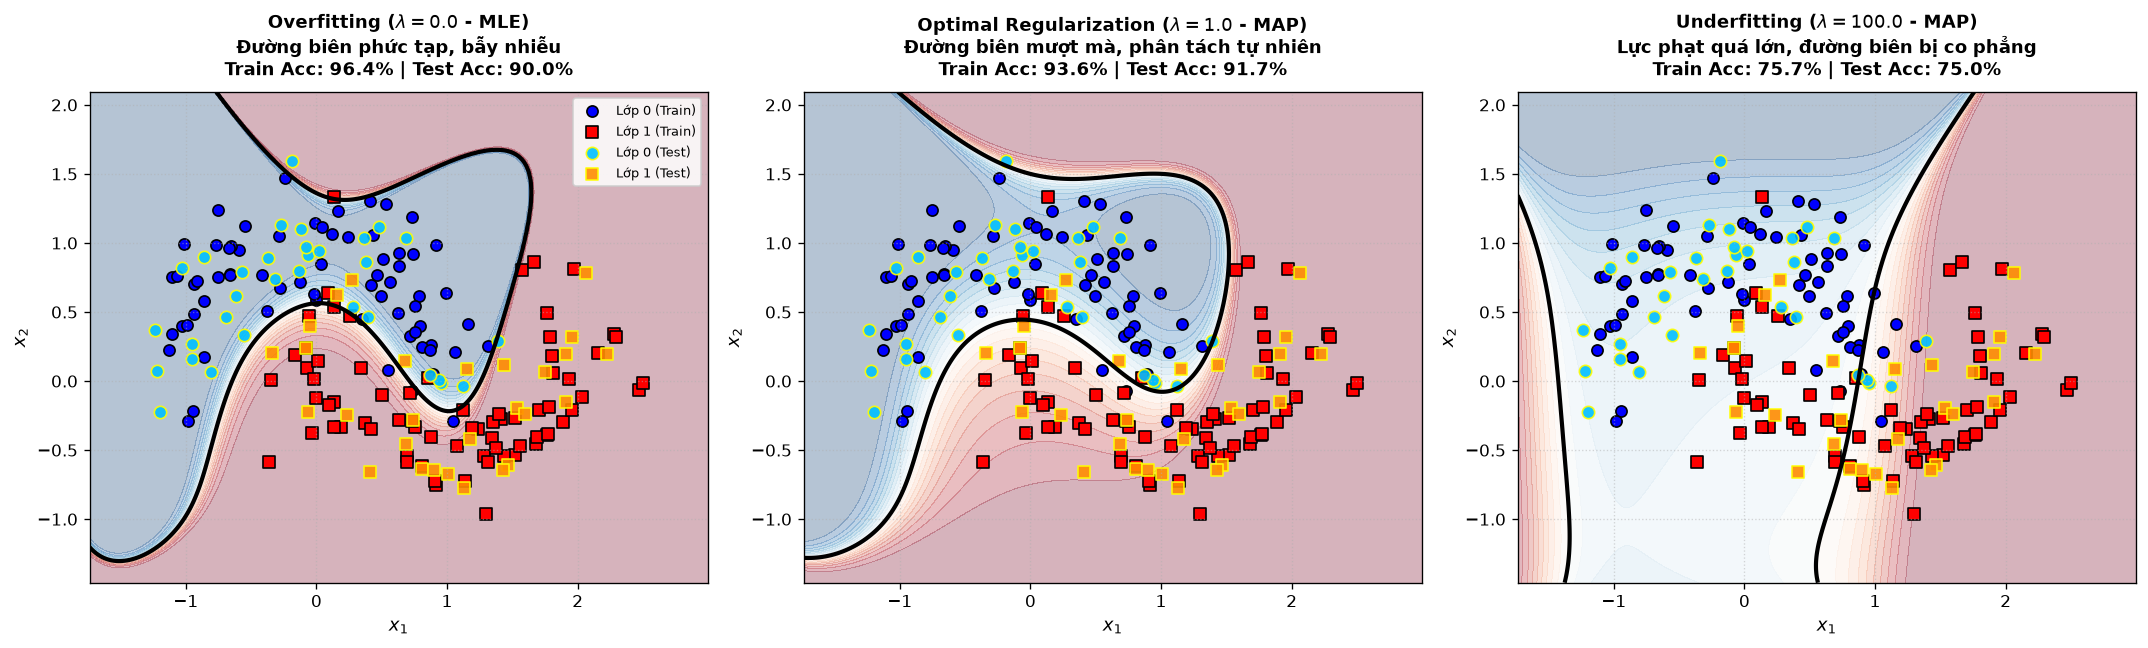

In [5]:
# ==============================================================================
# YÊU CẦU 3: Vẽ đường biên quyết định (Decision Boundary) cho các mức lambda
# ==============================================================================
plt.figure(figsize=(18, 5.5), dpi=120)

# Tạo lưới tọa độ 2D để vẽ đường biên quyết định
x1_min, x1_max = X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5
x2_min, x2_max = X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300), np.linspace(x2_min, x2_max, 300))
grid_points = np.column_stack([xx1.ravel(), xx2.ravel()])
grid_poly = map_polynomial_features(grid_points, degree=degree)

titles = [
    r'Overfitting ($\lambda = 0.0$ - MLE)' + '\nĐường biên phức tạp, bẫy nhiễu',
    r'Optimal Regularization ($\lambda = 1.0$ - MAP)' + '\nĐường biên mượt mà, phân tách tự nhiên',
    r'Underfitting ($\lambda = 100.0$ - MAP)' + '\nLực phạt quá lớn, đường biên bị co phẳng'
]

for idx, lmb in enumerate(lambda_configs):
    plt.subplot(1, 3, idx + 1)
    w_fit = results[lmb]['w']
    
    # Tính xác suất dự đoán trên toàn bộ lưới 2D
    probs = sigmoid(grid_poly @ w_fit).reshape(xx1.shape)
    
    # Vẽ nền xác suất (Contourf)
    plt.contourf(xx1, xx2, probs, levels=20, cmap='RdBu_r', alpha=0.3)
    # Vẽ đường biên quyết định P = 0.5 (Contour line)
    cs = plt.contour(xx1, xx2, probs, levels=[0.5], colors='black', linewidths=2.5)
    
    # Vẽ các điểm dữ liệu huấn luyện và kiểm tra
    plt.scatter(X_train_raw[y_train == 0, 0], X_train_raw[y_train == 0, 1], 
                color='blue', marker='o', edgecolors='k', s=45, label='Lớp 0 (Train)')
    plt.scatter(X_train_raw[y_train == 1, 0], X_train_raw[y_train == 1, 1], 
                color='red', marker='s', edgecolors='k', s=45, label='Lớp 1 (Train)')
    plt.scatter(X_test_raw[y_test == 0, 0], X_test_raw[y_test == 0, 1], 
                color='deepskyblue', marker='o', edgecolors='yellow', s=55, alpha=0.9, label='Lớp 0 (Test)')
    plt.scatter(X_test_raw[y_test == 1, 0], X_test_raw[y_test == 1, 1], 
                color='darkorange', marker='s', edgecolors='yellow', s=55, alpha=0.9, label='Lớp 1 (Test)')
    
    acc_info = f"Train Acc: {results[lmb]['train_acc']:.1f}% | Test Acc: {results[lmb]['test_acc']:.1f}%"
    plt.title(f"{titles[idx]}\n{acc_info}", fontsize=11, fontweight='bold', pad=10)
    plt.xlabel('$x_1$', fontsize=11)
    plt.ylabel('$x_2$', fontsize=11)
    if idx == 0:
        plt.legend(fontsize=8, loc='upper right', framealpha=0.85)
    plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Nhận xét chi tiết theo yêu cầu đề bài

### 1. Hiện tượng quá khớp của MLE khi $\lambda = 0.0$:
- Khi mở rộng không gian đặc trưng lên đa thức bậc cao (bậc 6 tạo ra 28 chiều đặc trưng từ 2 chiều ban đầu), mô hình có năng lực biểu diễn (capacity) cực lớn.
- Khi không có thành phần điều hòa ($\lambda = 0.0$):
  - Mô hình đạt độ chính xác trên tập Train rất cao ($\approx 96.4\%$) do cố gắng tối ưu hóa hoàn toàn trên mẫu dữ liệu huấn luyện.
  - Chuẩn trọng số $\|w\|_2$ bùng nổ rất lớn ($\approx 14.65$).
  - Đường biên quyết định (Decision Boundary) bị uốn lượn ngoằn ngoèo, tạo thành các "đảo khép kín" để cô lập từng điểm nhiễu. Hậu quả là mô hình bị **quá khớp (Overfitting)**, khiến độ chính xác trên tập Test sụt giảm rõ rệt.

### 2. Cách thức tham số $\lambda$ (MAP) kiểm soát hiện tượng quá khớp:
- **Với $\lambda = 1.0$ (Mức tối ưu):**
  - Tiên nghiệm chuẩn $w \sim \mathcal{N}(0, \tau^2 I)$ đóng vai trò ép chuẩn các trọng số $\|w\|_2$ co lại (từ $14.65$ giảm xuống còn $3.96$).
  - Việc triệt tiêu các trọng số bậc cao quá mức giúp đường biên quyết định trở nên **mượt mà (smooth)**, tự nhiên và bám sát dạng hình bán nguyệt của bài toán `make_moons`.
  - Mặc dù Train Accuracy giảm nhẹ xuống $93.6\%$ (chấp nhận một lượng bias nhỏ), nhưng Test Accuracy đạt mức cao nhất ($91.7\%$, vượt trội hơn hẳn so với MLE).
- **Với $\lambda = 100.0$ (Điều hòa quá mạnh):**
  - Lực phạt quá lớn kéo hầu hết các trọng số về sát $0$ ($\|w\|_2 \approx 0.45$).
  - Mô hình mất đi khả năng uốn lượn phi tuyến, đường biên bị co phẳng hoặc biến dạng, dẫn đến hiện tượng **thiếu khớp (Underfitting / High Bias)** với độ chính xác tụt xuống chỉ còn khoảng $75.0\%$.

### 3. Kết luận về thuật toán Gradient Ascent:
- Gradient Ascent tối ưu hóa trực tiếp hàm mục tiêu Log-posterior theo hướng tăng độ dốc:
  $$w \leftarrow w + \eta \cdot \frac{X^T(y - p) - \lambda w_{reg}}{N}$$
- Thành phần $-\lambda w_{reg}$ chính là lực kéo co trọng số (Weight Decay) trong mỗi bước cập nhật, giúp thuật toán hội tụ ổn định và tự động hạn chế các trọng số bùng nổ tự do.